In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/Users/mariusschonberg/Desktop/Speciale/code/models")
from Utils import FEATURES, load_shots, _encode_features, _impute_with_train_median, _pooled_auc, _pooled_ll

In [2]:
# load data
#Vi læser den samlede CSV-fil med alle 5056 skud fra alle 192 kampe i Superliga 2024/25. Vi printer antal skud og målrate som en hurtig sanity check.


df = pd.read_csv("/Users/mariusschonberg/Desktop/Speciale/outputs/outputs/all_matches_features_final.csv")
print(f"Skud i alt: {len(df)}")
print(f"Mål: {df['is_goal'].sum()} ({df['is_goal'].mean()*100:.1f}%)")

Skud i alt: 4957
Mål: 590 (11.9%)


In [3]:
#Vi gemmer navnene på de 15 features som en liste. Det er vigtigt at gøre dette her — før vi encoder — fordi _encode_features returnerer et numpy array uden kolonnenavne.

feature_names = df[FEATURES].columns.tolist()

In [4]:
# Vi konverterer vores feature-dataframe til et numpy array. Kategoriske kolonner som shot_body_part og play_pattern bliver label-encodet til tal. Alle numeriske kolonner sikres som float.
# forbered features — encode kategoriske variable og konverter til numpy array
X = _encode_features(df[FEATURES])
y = df["is_goal"].astype(int).to_numpy()

In [5]:
# 80/20 split — 80% til træning, 20% til test
# stratify=y sikrer samme andel mål i begge sæt
# random_state=42 sikrer reproducerbart split
#Vi deler data i 80% træning og 20% test med stratify=y så begge sæt har samme andel mål. random_state=42 sikrer at splittet er reproducerbart — det samme split bruges i alle vores modeller

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 3965, Test: 992


In [6]:
X_train, X_test = _impute_with_train_median(X_train, X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.neural_network import MLPClassifier

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
sample_weight = np.where(y_train == 1, n_neg / n_pos, 1.0)

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=1000,
    random_state=42,
)
model.fit(X_train_scaled, y_train, sample_weight=sample_weight)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [8]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [9]:
import shap
background = shap.kmeans(X_train_scaled, 50)
explainer = shap.KernelExplainer(model.predict_proba, background)
shap_values = explainer.shap_values(X_test_scaled, nsamples=100)

  0%|          | 0/992 [00:00<?, ?it/s]

In [10]:
print(type(shap_values))
print(len(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
992
(992, 15, 2)


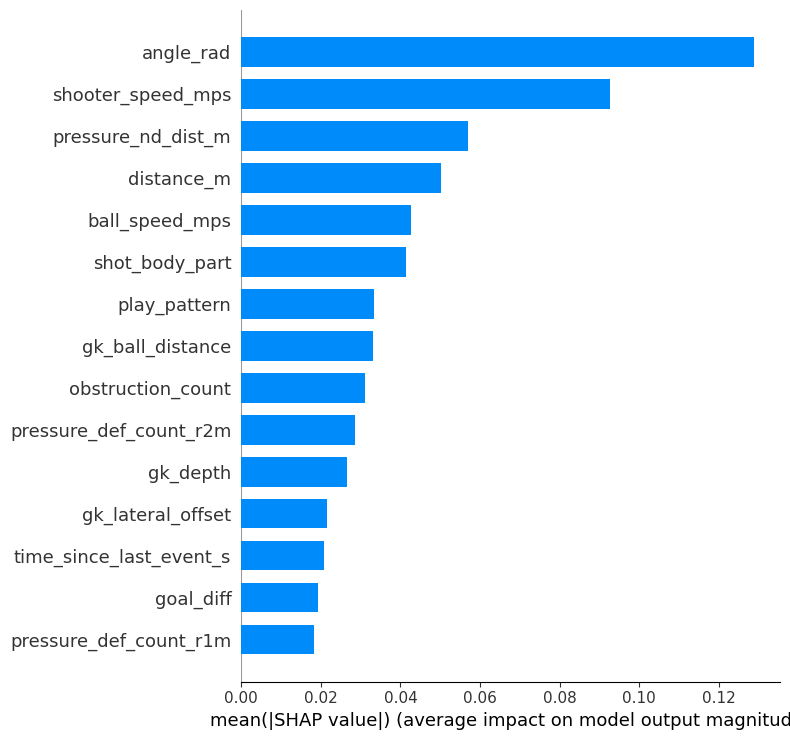

In [11]:
# Cell 10 — bar plot
# Vi laver et bar plot der viser den gennemsnitlige absolutte SHAP-værdi per feature. shap_values[1] er SHAP-værdierne for klasse 1 (mål). show=False forhindrer at plottet vises før vi har gemt det. Vi gemmer figuren direkte i thesis/figures/ så den er klar til Overleaf.
# Cell 10 — bar plot

shap.summary_plot(shap_values[:, :, 1], X_test_scaled, feature_names=feature_names, show=False)
plt.savefig("/Users/mariusschonberg/Desktop/Speciale/thesis/figures/shap_mlp_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
import numpy as np
import pandas as pd

vals = np.abs(shap_values[:, :, 1]).mean(axis=0)
top = pd.Series(vals, index=feature_names).sort_values(ascending=False)
print("=== SHAP Feature Importance: MLP ===")
print(top.to_string())

angle_rad             0.128865
shooter_speed_mps     0.092585
pressure_nd_dist_m    0.056927
distance_m            0.050300
ball_speed_mps        0.042641
dtype: float64
